<a href="https://colab.research.google.com/github/CplSwofford/Signal_Systems/blob/Valid_top1-98_top5-98/ISS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# needed
import os
import re
import soundfile as sf
from IPython.display import Audio
from IPython.display import display
import numpy as np
# recommended ...
from scipy import signal
from scipy.io import wavfile
from scipy.fft import fft, ifft, fftfreq
import scipy.io
import matplotlib.pyplot as plt


# added by me (from iSS scripts):
from scipy.signal import spectrogram
import librosa


In [2]:
# read data
login = "239468"
zip_file = "known" + ".zip"
for name in ("known.zip", "valid.zip", login + ".zip"):
  file = "https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/" + name
  !rm $name
  !wget $file
  !unzip -o -q $name

rm: cannot remove 'known.zip': No such file or directory
--2025-11-11 20:04:56--  https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/known.zip
Resolving www.fit.vut.cz (www.fit.vut.cz)... 147.229.9.65, 2001:67c:1220:809::93e5:941
Connecting to www.fit.vut.cz (www.fit.vut.cz)|147.229.9.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 210919709 (201M) [application/zip]
Saving to: ‘known.zip’

known.zip           100%[===================>] 201.15M  19.8MB/s    in 16s     

2025-11-11 20:05:13 (12.9 MB/s) - ‘known.zip’ saved [210919709/210919709]

rm: cannot remove 'valid.zip': No such file or directory
--2025-11-11 20:05:17--  https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/valid.zip
Resolving www.fit.vut.cz (www.fit.vut.cz)... 147.229.9.65, 2001:67c:1220:809::93e5:941
Connecting to www.fit.vut.cz (www.fit.vut.cz)|147.229.9.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7608498 (7.3M) [application/zip]
Saving to:

In [3]:
# load the known data - the function returns a big matrix with all the signals
def load_data (S, dirname, count, no_samples):
  ii = 0
  for one in np.arange(count):
    S[ii], Fs = sf.read(dirname + "/" + str(one) + ".wav")
    ii = ii+1

Fs = 16000
# load known data
N_known = 706; duration_known = 10; no_samples_known = Fs * duration_known
known_signals=np.zeros([N_known, no_samples_known]); load_data(known_signals, "known", N_known, no_samples_known)
#display(Audio(known_signals[45], rate=Fs))

# load validation data
N_valid = 50; duration_valid = 5; no_samples_valid = Fs * duration_valid
valid_signals= np.zeros([N_valid, no_samples_valid]); load_data(valid_signals, "valid", N_valid, no_samples_valid)
#display(Audio(valid_signals[45], rate=Fs))

Vzorkovací frekvence (known):  16000 1D pole s 10ti vzorky (první known signál):  [-1073  -897  -695  -458  -185   127   462   805  1142  1451]
Nanormovaných prvních 10 vzorků první skladby):  [-0.03274536 -0.02737427 -0.02120972 -0.01397705 -0.00564575  0.00387585
  0.01409955  0.0245674   0.03485214  0.04428236]


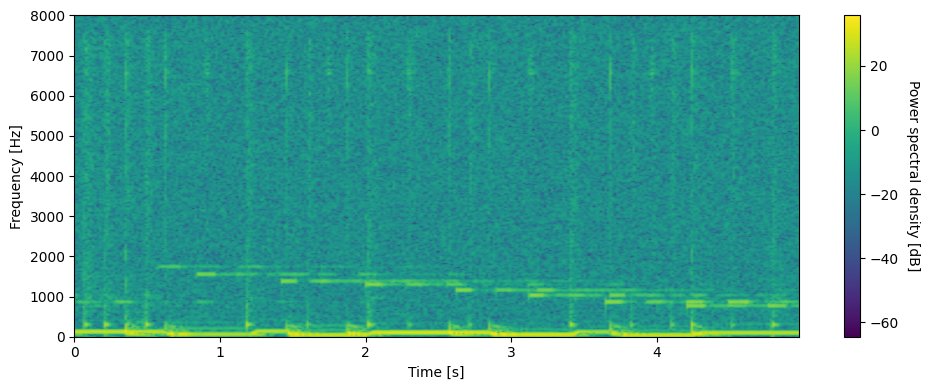

Frekvenční osa (prvních 10 hodnot):  [  0.     15.625  31.25   46.875  62.5    78.125  93.75  109.375 125.
 140.625]
Rekonstruovaný 1. rámec (prvních 10 vzorků):  [ 1.96463601e-04 -1.25250726e-04  1.44431459e-04 -9.87227751e-05
  9.03778495e-05 -1.63148251e-04  3.13605628e-05 -2.35293651e-04
  1.38035784e-06 -2.63431913e-04]


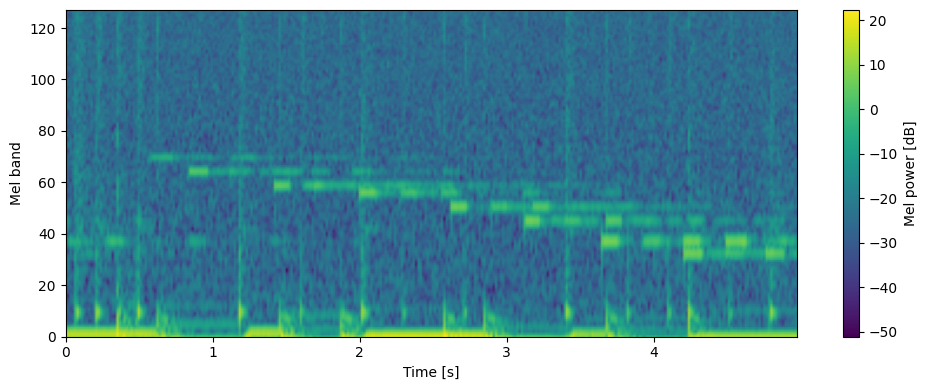

In [73]:
# YOUR CODE COMES HERE ! Your task is to produce a matrix 50 x 706 with similarity measures

# COUNT number of sound clips
def sound_clips(folder):
    return sum(len(files) for _, _, files in os.walk(folder))


# GET number of sound clips
known_snound_clips_num = sound_clips("known")   #706
valid_snound_clips_num = sound_clips("valid")   #51
#print(known_snound_clips_num)
#print(valid_snound_clips_num)




known_Fs, known_samples = wavfile.read(f"known/{0}.wav")    #16000, #160000
print("Vzorkovací frekvence (known): ", known_Fs, "1D pole s 10ti vzorky (první known signál): ", known_samples[:10])
"""
Délka jedné skladby - 10s x vzorkovací frekvence 16000 Hz (tzv. 16000 vzorků za sekundu) = 160000 vzorků za 10s     (u valid 5x16000 = 80000)
Každé číslo reprezentuje okamžitou hodnotu amplitudy
"""
#print(known_samples.shape, known_samples.dtype)
known_sample_len = known_samples.shape[0]
#print(known_Fs, known_samples.shape, known_samples.dtype)
#print(known_samples[:10])

valid_Fs, valid_samples = wavfile.read(f"valid/{0}.wav")    #16000, #80000
valid_sample_len = valid_samples.shape[0]
#print(valid_Fs, valid_samples.shape, valid_samples.dtype)
#print(valid_samples[:10])





# EMPTY Vectors - for saving normalized values
valid_vec = np.zeros((valid_snound_clips_num, valid_sample_len), dtype=np.float32)
known_vec = np.zeros((known_snound_clips_num, known_sample_len), dtype=np.float32)
#print(known_vec[:10])
#print(known_vec.shape)


# NORMALIAUTION function: from −32768 -> +32767  to -1 -> 1
"""
Normalizace funcke, převední rozsahů hodnot od −32768 do +32767 na -1 do +1
"""
def int16_to_unit_closed(x):
    xf = x.astype(np.float32)
    return np.where(xf < 0, xf / 32768.0, xf / 32767.0).astype(np.float32)


def norming(folder: str, n_files: int, out_mat: np.ndarray):
    for i in range(n_files):
        _, s = wavfile.read(f"{folder}/{i}.wav")
        """
        if getattr(s, "ndim", 1) == 2:   # stereo -> mono
            s = s.mean(axis=1)
            """
        out_mat[i, :] = int16_to_unit_closed(s)

# Calling
norming("valid", valid_snound_clips_num-1, valid_vec)   # -1 bcs of 51 ???
norming("known", known_snound_clips_num, known_vec)

test_known_vec = known_vec[0]
print("Nanormovaných prvních 10 vzorků první skladby): ", test_known_vec[:10])




# Framing:
"""
Framing - rozřeže 1D signál a na rámce délky frame_len se skokem frame_shift
výstup - matice [počet rámců X délka rámce], každý řádek je jeden ůsek signálu připravený
k vynásobením oknem


vzorky    |----------400------------------|----------400--------------------|--------
frame 1:  [0.............................400)
frame 2:               [160.............................560)
frame 3:                              [320.............................720)

"""

def framing(a, frame_len, frame_shift=1):
    """
    from 03_spectral_2.ipynb   by profesor Černocký

    upraveno pro padding - doplňují se nuly aby vyšel plný poslední rámec
    """
    a = np.asarray(a)
    L = a.shape[0]

    if L < frame_len:
        pad_amount = frame_len - L
    else:
        rem = (L - frame_len) % frame_shift
        pad_amount = 0 if rem == 0 else (frame_shift - rem)
    if pad_amount > 0:
        a = np.pad(a, (0, pad_amount), mode='constant', constant_values=0.0)
        L = a.shape[0]

    a = np.ascontiguousarray(a)

    if L < frame_len:
        return np.empty((0, frame_len), dtype=a.dtype)

    n_frames = 1 + (L - frame_len) // frame_shift
    shape   = (n_frames, frame_len) + a.shape[1:]
    strides = (a.strides[0]*frame_shift, a.strides[0]) + a.strides[1:]
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides)




from scipy.signal.windows import hann, hamming, blackmanharris, kaiser

def spectrogram(x, window, noverlap=None, nfft=None):
    """
    from 03_spectral_2.ipynb   by profesor Černocký
    """
    if np.isscalar(window):

        """
        Okenní funkce:
        """
        #window = np.hamming(int(window))
        #window = np.hanning(int(window))
        window = kaiser(int(window), beta=8.6)
        #window = blackmanharris(int(window))


    if noverlap is None:
        noverlap = window.size // 2
    if nfft is None:
        nfft = window.size

    hop = window.size - noverlap
    Xfrm = framing(x, window.size, hop)

    W = window[None, :]
    Xfull = fft(Xfrm * W, n=nfft, axis=1)
    X = Xfull[:, : nfft//2 + 1]

    return X


def show_spectrogram(X, fs, nfft, frame_shift):
    """
    from 03_spectral_2.ipynb   by profesor Černocký
    """
    # osy
    f = np.arange(0, nfft//2 + 1) * fs / nfft
    t = np.arange(0, X.shape[0]) * frame_shift / fs

    # výpočet logaritmického výkonového spektra
    sgr_log = 10 * np.log10(np.real(np.conj(X.T) * X.T) + 1e-20)

    # zobrazení
    plt.figure(figsize=(10,4))
    plt.pcolormesh(t, f, sgr_log, shading='gouraud', cmap="viridis")
    plt.xlabel('Time [s]')
    plt.ylabel('Frequency [Hz]')
    cbar = plt.colorbar()
    cbar.set_label('Power spectral density [dB]', rotation=270, labelpad=15)
    plt.tight_layout()
    plt.show()



N = 512          #délka okna/rámce
Nfft = 1024          #velikost FFT. Musí být ≥ N
"""
Nfft je počet bodů FFT použitý pro každý rámec při výpočtu spektrogramu/STFT.
Určuje, na kolik „kousků“ rozsekáš pásmo 0…Fs/2.
Dostaneme diskrétní spektrum složené z kousků
Každý kousek odpovídá jedné diskrétní frekvenc
K každém kousku komplex. číslo:
                          1. magnituda - enegie v daném čase
                          2. fáze - čas. posunutí složky

jemnější mřížka frekvencí = přesnější odečítání frekvence a hezčí graf.
 """

overlap = 256      #překryv rámců ve vzorcích. Kolik vzorků sousední rámce sdílí.
hop = N - overlap   #posun (frame shift) mezi začátky rámců



X = spectrogram(valid_vec[0], N, overlap, Nfft)
show_spectrogram (X, valid_Fs, Nfft, hop)


f = fftfreq(Nfft, d=1/valid_Fs)
frame_time = ifft(X[0], n=Nfft).real

print("Frekvenční osa (prvních 10 hodnot): ", f[:10])
print("Rekonstruovaný 1. rámec (prvních 10 vzorků): ", frame_time[:10])



# After scaling still same, just check
display(Audio(valid_vec[0], rate=valid_Fs))
display(Audio(f"valid/{0}.wav", rate=valid_Fs))





#########################################################################################
def mel_db(X, fs, nfft, n_mels=64, fmin=100, fmax=6000, eps=1e-10):
    S = (np.abs(X)**2).T                                                             # (bins × frames)
    H = librosa.filters.mel(sr=fs, n_fft=nfft, n_mels=n_mels, fmin=fmin, fmax=fmax)  # (mels × bins)
    return 10*np.log10(H @ S + eps)

M = mel_db(X, fs=valid_Fs, nfft=Nfft, n_mels=128, fmin=100, fmax=6000)

t = np.arange(M.shape[1]) * (hop / valid_Fs)
y = np.arange(M.shape[0])
plt.figure(figsize=(10,4))
plt.pcolormesh(t, y, M, shading='gouraud')
plt.xlabel('Time [s]')
plt.ylabel('Mel band')
plt.colorbar(label='Mel power [dB]')
plt.tight_layout()
#########################################################################################


n_mels = 96
fmin, fmax = 80, 1400


##########################################################################################
def clip_to_embedding(x):

    X = spectrogram(x, np.hanning(N), overlap, Nfft)   # komplexní STFT (frames × bins)
    M = mel_db(X, fs=Fs, nfft=Nfft, n_mels=n_mels, fmin=fmin, fmax=fmax)  # (mels × frames), dB
    emb = M.mean(axis=1)  # průměr přes čas → (mels,)


    # Nepoužíva:  Top1 - 2 a Top5 - 12
    #XdB = 20*np.log10(np.abs(X) + 1e-10)                        # log-magnitude v dB
    #emb = XdB.mean(axis=0)

    return emb


known_emb = np.vstack([clip_to_embedding(known_vec[j]) for j in range(known_vec.shape[0])])  # shape (706, n_mels)
known_norm = np.linalg.norm(known_emb, axis=1, keepdims=True) + 1e-12  # (706,1)


##########################################################################################



N_valid = 50

def compute_similarity_matrix(N_valid, N_known):
  # complete stupid solution just for testing the evaluation ...
  # the full version will probably have more arguments !
  similarities = np.random.uniform( 0, 1, (N_valid, N_known))

  for i in range(N_valid):
      v = clip_to_embedding(valid_vec[i])                      # (n_mels,)
      vnorm = np.linalg.norm(v) + 1e-12
      sims = (known_emb @ v) / (known_norm.ravel() * vnorm)    # (706,)
      similarities[i, :] = sims

  return similarities




In [74]:
# evaluation - the function produces Top-1 and Top-5 accuracy on validation data
def eval(scores, key):
  indices = np.flip(np.argsort(scores), axis=-1) # we want highest to lowest ...
  #print(scores[0,key[0]], key[0], indices)
  top1acc = np.sum(key == indices[:,0]) / indices.shape[0]
  top5acc = 0
  for ii in range(5):
    top5acc += np.sum(key == indices[:,ii])
  top5acc /=  indices.shape[0]

  print(top1acc)
  print(top5acc)
  return top1acc, top5acc

key = np.loadtxt("valid/key.txt", delimiter = ',', usecols=(1), dtype ='int')



N_valid, N_known = 50, 706
scores_matrix = compute_similarity_matrix(N_valid, N_known)
key_used = key[:scores_matrix.shape[0]]
top1, top5 = eval(scores_matrix, key_used)
print(f"Top-1: {top1*100:.1f}%  |  Top-5: {top5*100:.1f}%")


np.savetxt("eval.txt", scores_matrix)
print(scores_matrix.shape[0], scores_matrix.shape[1])

0.98
0.98
Top-1: 98.0%  |  Top-5: 98.0%
50 706
